# Benchmarking Mistral & DeepSeek (via Ollama) on Open-Source Datasets

Author: Nimai Chand Das Adhikari
Reviewed By:
Team: Microsoft/Azure-Migrate

This notebook:
1. Pulls multiple **Mistral** and **DeepSeek** model variants through **Ollama**
2. Captures **device specs** (CPU, RAM, GPU, OS) before/during runs
3. Runs inference over selected **open-source datasets** (HellaSwag, GSM8K, TruthfulQA, MMLU sample, ARC) — using small subsets so it runs in reasonable time
4. Records per-call **latency, tokens/sec, prompt/completion tokens, RAM/GPU memory usage**
5. Computes simple **accuracy/quality metrics** where ground truth is available
6. Saves results to **CSV/JSON** and shows summary tables + plots

## Prerequisites
- **Ollama** installed and running locally: https://ollama.com (the daemon must be reachable at `http://localhost:11434`)
- Python ≥ 3.9
- Disk space for model weights (each model can be 2–10+ GB)

> Tip: We will start with smaller variants (e.g., `mistral:7b-instruct-q4_K_M`, `deepseek-r1:1.5b`) to validate the pipeline before pulling larger ones.
> Tip: In the next Run we will have larger models to check. We will keep a concept of Early stopping for Inference Time

## 1. Install Python dependencies

In [1]:
%pip install -q -U requests psutil pandas matplotlib datasets tqdm
# GPUtil is optional; pynvml gives more accurate NVIDIA stats
%pip install -q -U pynvml GPUtil

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\dasadhikarin\\PyCharmMiscProject\\.venv\\Lib\\site-packages\\matplotlib\\stackplot.py'
Check the permissions.


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Verify Ollama is running

If this cell fails, start the Ollama service:
- **Windows / macOS:** launch the Ollama app
- **Linux:** `ollama serve` in a separate terminal

In [2]:
import requests
OLLAMA_URL = 'http://localhost:11434'

try:
    r = requests.get(f'{OLLAMA_URL}/api/tags', timeout=5)
    r.raise_for_status()
    print('Ollama is reachable. Installed models:')
    for m in r.json().get('models', []):
        print(' -', m['name'], f"({m.get('size', 0) / 1e9:.2f} GB)")
except Exception as e:
    print('Could not reach Ollama:', e)
    print('Start the Ollama daemon and re-run this cell.')

Ollama is reachable. Installed models:
 - deepseek-r1:latest (5.23 GB)
 - mistral:latest (4.37 GB)


## 3. Capture device / system specifications

In [3]:
import platform, psutil, json, shutil, subprocess, os

def get_gpu_info():
    """Return a list of dicts describing detected GPUs (NVIDIA via pynvml, fallback to GPUtil)."""
    gpus = []
    # Try NVIDIA via pynvml
    try:
        import pynvml
        pynvml.nvmlInit()
        for i in range(pynvml.nvmlDeviceGetCount()):
            h = pynvml.nvmlDeviceGetHandleByIndex(i)
            mem = pynvml.nvmlDeviceGetMemoryInfo(h)
            gpus.append({
                'index': i,
                'name': pynvml.nvmlDeviceGetName(h),
                'memory_total_gb': round(mem.total / 1e9, 2),
                'memory_used_gb': round(mem.used / 1e9, 2),
                'driver': pynvml.nvmlSystemGetDriverVersion(),
                'vendor': 'NVIDIA',
            })
        pynvml.nvmlShutdown()
    except Exception:
        pass
    # Fallback / additional info via GPUtil
    if not gpus:
        try:
            import GPUtil
            for g in GPUtil.getGPUs():
                gpus.append({
                    'index': g.id, 'name': g.name,
                    'memory_total_gb': round(g.memoryTotal / 1024, 2),
                    'memory_used_gb': round(g.memoryUsed / 1024, 2),
                    'driver': getattr(g, 'driver', 'unknown'),
                    'vendor': 'NVIDIA',
                })
        except Exception:
            pass
    return gpus

DEVICE_INFO = {
    'os': f'{platform.system()} {platform.release()}',
    'os_version': platform.version(),
    'machine': platform.machine(),
    'processor': platform.processor(),
    'cpu_logical_cores': psutil.cpu_count(logical=True),
    'cpu_physical_cores': psutil.cpu_count(logical=False),
    'ram_total_gb': round(psutil.virtual_memory().total / 1e9, 2),
    'ram_available_gb': round(psutil.virtual_memory().available / 1e9, 2),
    'disk_free_gb': round(shutil.disk_usage(os.getcwd()).free / 1e9, 2),
    'python': platform.python_version(),
    'gpus': get_gpu_info(),
    'gpu_available': bool(get_gpu_info()),
}
print(json.dumps(DEVICE_INFO, indent=2, default=str))

{
  "os": "Windows 11",
  "os_version": "10.0.26200",
  "machine": "AMD64",
  "processor": "Intel64 Family 6 Model 106 Stepping 6, GenuineIntel",
  "cpu_logical_cores": 16,
  "cpu_physical_cores": 8,
  "ram_total_gb": 68.67,
  "ram_available_gb": 45.66,
  "disk_free_gb": 373.79,
  "python": "3.14.0",
  "gpus": [],
  "gpu_available": false
}


## 4. Configure models and pull them via Ollama

Edit `MODELS` to add/remove variants. Common tags (verify on https://ollama.com/library):
- **Mistral:** `mistral:7b-instruct`, `mistral:7b-instruct-q4_K_M`, `mistral-nemo:12b`, `mixtral:8x7b`
- **DeepSeek:** `deepseek-r1:1.5b`, `deepseek-r1:7b`, `deepseek-r1:8b`, `deepseek-coder:6.7b`, `deepseek-llm:7b`

In [4]:
MODELS = [
    'mistral:7b-instruct-q4_K_M',
    'deepseek-r1:1.5b',
    'deepseek-r1:7b',
    # 'mixtral:8x7b',          # very large – uncomment if you have the VRAM/RAM
    # 'deepseek-coder:6.7b',
]

def ollama_pull(model: str):
    """Stream a pull request and print progress lines."""
    print(f'\n>>> Pulling {model} ...')
    with requests.post(f'{OLLAMA_URL}/api/pull', json={'name': model}, stream=True, timeout=None) as r:
        r.raise_for_status()
        last_status = None
        for line in r.iter_lines():
            if not line:
                continue
            try:
                data = json.loads(line.decode('utf-8'))
            except Exception:
                continue
            status = data.get('status')
            if status and status != last_status:
                print('  ', status)
                last_status = status
            if data.get('error'):
                raise RuntimeError(data['error'])
    print(f'<<< Done: {model}')

for m in MODELS:
    try:
        ollama_pull(m)
    except Exception as e:
        print(f'Failed to pull {m}: {e}')


>>> Pulling mistral:7b-instruct-q4_K_M ...
   pulling manifest
   pulling faf975975644
   pulling 43070e2d4e53
   pulling 22e1b2e8dc2f
   pulling ed11eda7790d
   pulling 126aeb334a49
   verifying sha256 digest
   writing manifest
   success
<<< Done: mistral:7b-instruct-q4_K_M

>>> Pulling deepseek-r1:1.5b ...
   pulling manifest
   pulling aabd4debf0c8
   pulling c5ad996bda6e
   pulling 6e4c38e1172f
   pulling f4d24e9138dd
   pulling a85fe2a2e58e
   verifying sha256 digest
   writing manifest
   success
<<< Done: deepseek-r1:1.5b

>>> Pulling deepseek-r1:7b ...
   pulling manifest
   pulling 96c415656d37
   pulling c5ad996bda6e
   pulling 6e4c38e1172f
   pulling f4d24e9138dd
   pulling 40fb844194b2
   verifying sha256 digest
   writing manifest
   success
<<< Done: deepseek-r1:7b


### 4b. Discover each model's total token capacity (context window)

We call `/api/show` and read the model's metadata to extract:
- **`context_length`** — the maximum total tokens (prompt + completion) the model can handle
- **parameter count, quantization, family, size on disk**

This tells you the absolute upper bound on tokens you can feed any single request.

In [ ]:
def get_model_info(model: str) -> dict:
    """Return metadata for an Ollama model, including its max context window."""
    info = {'model': model, 'context_length': None, 'parameter_count': None,
            'quantization': None, 'family': None, 'size_gb': None}
    try:
        r = requests.post(f'{OLLAMA_URL}/api/show', json={'name': model}, timeout=30)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        info['error'] = str(e)
        return info

    details = data.get('details', {}) or {}
    info['family'] = details.get('family')
        
    info['quantization'] = details.get('quantization_level')
    info['parameter_size'] = details.get('parameter_size')

    # `model_info` is a flat dict with arch-prefixed keys, e.g. 'llama.context_length'
    model_info = data.get('model_info', {}) or {}
    for k, v in model_info.items():
        if k.endswith('.context_length') and info['context_length'] is None:
            info['context_length'] = v
        elif k.endswith('.embedding_length'):
            info['embedding_length'] = v
        elif k == 'general.parameter_count':
            info['parameter_count'] = v

    # File size from /api/tags
    try:
        tags = requests.get(f'{OLLAMA_URL}/api/tags', timeout=10).json().get('models', [])
        for entry in tags:
            if entry['name'] == model:
                info['size_gb'] = round(entry.get('size', 0) / 1e9, 2)
                break
    except Exception:
        pass
    return info

MODEL_INFO = {m: get_model_info(m) for m in MODELS}
for m, info in MODEL_INFO.items():
    ctx = info.get('context_length')
    print(f"{m}: context_length={ctx} tokens | params={info.get('parameter_size')} | quant={info.get('quantization')} | size={info.get('size_gb')} GB")

## 5. Inference helper with metrics

We call Ollama's `/api/generate` (non-streaming) which returns timing fields:
- `total_duration`, `load_duration`, `prompt_eval_count`, `prompt_eval_duration`, `eval_count`, `eval_duration` (all nanoseconds)

We also sample **process RAM** and **GPU memory** before/after each call.

In [5]:
import time
from typing import Optional

def gpu_mem_used_gb() -> Optional[float]:
    try:
        import pynvml
        pynvml.nvmlInit()
        total = 0
        for i in range(pynvml.nvmlDeviceGetCount()):
            h = pynvml.nvmlDeviceGetHandleByIndex(i)
            total += pynvml.nvmlDeviceGetMemoryInfo(h).used
        pynvml.nvmlShutdown()
        return round(total / 1e9, 3)
    except Exception:
        return None

def ram_used_gb() -> float:
    vm = psutil.virtual_memory()
    return round((vm.total - vm.available) / 1e9, 3)

def ollama_generate(model: str, prompt: str, max_tokens: int = 256, temperature: float = 0.0):
    payload = {
        'model': model,
        'prompt': prompt,
        'stream': False,
        'options': {'num_predict': max_tokens, 'temperature': temperature},
    }
    ram_before = ram_used_gb()
    gpu_before = gpu_mem_used_gb()
    t0 = time.perf_counter()
    r = requests.post(f'{OLLAMA_URL}/api/generate', json=payload, timeout=600)
    wall = time.perf_counter() - t0
    r.raise_for_status()
    data = r.json()
    ram_after = ram_used_gb()
    gpu_after = gpu_mem_used_gb()

    eval_count = data.get('eval_count', 0) or 0
    eval_duration_ns = data.get('eval_duration', 0) or 0
    prompt_count = data.get('prompt_eval_count', 0) or 0
    prompt_duration_ns = data.get('prompt_eval_duration', 0) or 0
    total_ns = data.get('total_duration', 0) or 0
    load_ns = data.get('load_duration', 0) or 0

    tokens_per_sec = (eval_count / (eval_duration_ns / 1e9)) if eval_duration_ns else None

    return {
        'response': data.get('response', '').strip(),
        'wall_seconds': round(wall, 4),
        'total_duration_s': round(total_ns / 1e9, 4),
        'load_duration_s': round(load_ns / 1e9, 4),
        'prompt_tokens': prompt_count,
        'prompt_eval_s': round(prompt_duration_ns / 1e9, 4),
        'completion_tokens': eval_count,
        'completion_eval_s': round(eval_duration_ns / 1e9, 4),
        'tokens_per_sec': round(tokens_per_sec, 2) if tokens_per_sec else None,
        'ram_before_gb': ram_before,
        'ram_after_gb': ram_after,
        'ram_delta_gb': round(ram_after - ram_before, 3),
        'gpu_before_gb': gpu_before,
        'gpu_after_gb': gpu_after,
        'gpu_delta_gb': round(gpu_after - gpu_before, 3) if (gpu_before is not None and gpu_after is not None) else None,
    }

# Smoke test
if MODELS:
    test = ollama_generate(MODELS[0], 'Reply with a single word: Hello.', max_tokens=10)
    print(json.dumps(test, indent=2))

{
  "response": "Hello.",
  "wall_seconds": 11.0257,
  "total_duration_s": 9.0052,
  "load_duration_s": 7.8104,
  "prompt_tokens": 19,
  "prompt_eval_s": 1.0038,
  "completion_tokens": 3,
  "completion_eval_s": 0.1887,
  "tokens_per_sec": 15.9,
  "ram_before_gb": 23.276,
  "ram_after_gb": 28.235,
  "ram_delta_gb": 4.959,
  "gpu_before_gb": null,
  "gpu_after_gb": null,
  "gpu_delta_gb": null
}


## 6. Load open-source evaluation datasets

We use small slices from each dataset to keep runtime manageable. Increase `N_SAMPLES` for more rigorous evaluation.

In [ ]:
from datasets import load_dataset

# Set to an int (e.g. 200) to cap per-dataset size. None = use full split.
MAX_ITEMS_PER_DATASET = None

def _split(base: str) -> str:
    return f'{base}[:{MAX_ITEMS_PER_DATASET}]' if MAX_ITEMS_PER_DATASET else base

def safe_load(loader_fn, name):
    try:
        return loader_fn()
    except Exception as e:
        print(f'[skip] {name}: {e}')
        return []

# --- GSM8K (grade-school math; exact-match on numeric final answer) ---
def load_gsm8k():
    ds = load_dataset('gsm8k', 'main', split=_split('test'))
    items = []
    for ex in ds:
        gold = ex['answer'].split('####')[-1].strip().replace(',', '')
        items.append({
            'dataset': 'gsm8k',
            'prompt': f"Solve the problem and end your answer with '#### <number>'.\n\nQuestion: {ex['question']}\nAnswer:",
            'gold': gold,
            'task_type': 'numeric_exact',
        })
    ds = load_dataset('hellaswag', split=_split('validation'))

# --- HellaSwag (commonsense; multiple choice) ---
def load_hellaswag():
    ds = load_dataset('hellaswag', split=f'validation[:{N_SAMPLES}]')
    items = []
    for ex in ds:
        choices = '\n'.join(f'{chr(65 + i)}. {c}' for i, c in enumerate(ex['endings']))
        items.append({
            'dataset': 'hellaswag',
            'prompt': (f"Choose the most likely continuation. Reply with only A, B, C, or D.\n\n"
                       f"Context: {ex['ctx']}\n{choices}\nAnswer:"),
            'gold': chr(65 + int(ex['label'])),
            'task_type': 'mcq',
        })
    ds = load_dataset('allenai/ai2_arc', 'ARC-Easy', split=_split('test'))

# --- ARC-Easy (science MCQ) ---
def load_arc():
    ds = load_dataset('allenai/ai2_arc', 'ARC-Easy', split=f'test[:{N_SAMPLES}]')
    items = []
    for ex in ds:
        labels = ex['choices']['label']
        texts = ex['choices']['text']
        choices = '\n'.join(f'{l}. {t}' for l, t in zip(labels, texts))
        items.append({
            'dataset': 'arc_easy',
            'prompt': (f"Answer with only the letter of the correct choice.\n\n"
                       f"Question: {ex['question']}\n{choices}\nAnswer:"),
            'gold': ex['answerKey'],
            'task_type': 'mcq',
        })
    ds = load_dataset('truthful_qa', 'generation', split=_split('validation'))

# --- TruthfulQA (open-ended; we just record latency / capture answers) ---
def load_truthfulqa():
    ds = load_dataset('truthful_qa', 'generation', split=f'validation[:{N_SAMPLES}]')
    items = []
    for ex in ds:
        items.append({
            'dataset': 'truthfulqa',
            'prompt': f"Answer truthfully and concisely.\n\nQuestion: {ex['question']}\nAnswer:",
            'gold': ex.get('best_answer', ''),
            'task_type': 'open',
        })
    ds = load_dataset('cais/mmlu', 'high_school_world_history', split=_split('test'))

# --- MMLU (sample subject) ---
def load_mmlu():
    ds = load_dataset('cais/mmlu', 'high_school_world_history', split=f'test[:{N_SAMPLES}]')
    items = []
    for ex in ds:
        choices = '\n'.join(f'{chr(65 + i)}. {c}' for i, c in enumerate(ex['choices']))
        items.append({
            'dataset': 'mmlu_world_history',
            'prompt': (f"Answer with only the letter (A, B, C, or D).\n\n"
                       f"Question: {ex['question']}\n{choices}\nAnswer:"),
            'gold': chr(65 + int(ex['answer'])),
            'task_type': 'mcq',
        })
    return items

EVAL_ITEMS = []
EVAL_ITEMS += safe_load(load_gsm8k,      'gsm8k')
EVAL_ITEMS += safe_load(load_hellaswag,  'hellaswag')
EVAL_ITEMS += safe_load(load_arc,        'arc_easy')
EVAL_ITEMS += safe_load(load_truthfulqa, 'truthfulqa')
EVAL_ITEMS += safe_load(load_mmlu,       'mmlu_world_history')

print(Counter(it['dataset'] for it in EVAL_ITEMS))

print('Total eval items:', len(EVAL_ITEMS))from collections import Counter

C:\Users\dasadhikarin\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating dev split: 100%|██████████| 5/5 [00:00<00:00, 278.85 examples/s]

Total eval items: 100
Counter({'gsm8k': 20, 'hellaswag': 20, 'arc_easy': 20, 'truthfulqa': 20, 'mmlu_world_history': 20})


## 7. Scoring helpers

In [8]:
import re

MCQ_RE = re.compile(r'\b([A-E])\b')
NUM_RE = re.compile(r'-?\d+(?:\.\d+)?')

def score(task_type: str, gold: str, prediction: str):
    pred = (prediction or '').strip()
    if task_type == 'mcq':
        # Prefer answer after '####' or last standalone letter
        m = MCQ_RE.findall(pred.upper())
        guess = m[0] if m else ''
        return int(guess == gold.upper()), guess
    if task_type == 'numeric_exact':
        # GSM8K convention: take number after '####' if present, else last number
        if '####' in pred:
            tail = pred.split('####')[-1]
            nums = NUM_RE.findall(tail)
        else:
            nums = NUM_RE.findall(pred)
        guess = nums[-1].replace(',', '') if nums else ''
        try:
            return int(float(guess) == float(gold)), guess
        except ValueError:
            return 0, guess
    return None, pred  # 'open' has no automatic score

## 8. Run the benchmark

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

MAX_NEW_TOKENS = 256
results = []

for model in MODELS:
    print(f'\n=== Benchmarking {model} ===')
    # Warm up (loads weights into RAM/VRAM so first measured call isn't biased by load time)
    try:
        ollama_generate(model, 'Hello.', max_tokens=4)
    except Exception as e:
        print(f'Warm-up failed for {model}: {e}; skipping.')
        continue

    for item in tqdm(EVAL_ITEMS, desc=model):
        max_tok = 384 if item['task_type'] == 'numeric_exact' else (8 if item['task_type'] == 'mcq' else MAX_NEW_TOKENS)
        try:
            out = ollama_generate(model, item['prompt'], max_tokens=max_tok)
            correct, guess = score(item['task_type'], item['gold'], out['response'])
            ctx_len = MODEL_INFO.get(model, {}).get('context_length')
            total_tokens = (out.get('prompt_tokens') or 0) + (out.get('completion_tokens') or 0)
            results.append({
                'model': model,
                'context_length': ctx_len,
                'dataset': item['dataset'],
                'task_type': item['task_type'],
                'gold': item['gold'],
                'prediction': out['response'][:300],
                'parsed_guess': guess,
                'correct': correct,
                'total_tokens': total_tokens,
                'context_utilization': round(total_tokens / ctx_len, 4) if ctx_len else None,
                **{k: v for k, v in out.items() if k != 'response'},
            })
        except Exception as e:
            results.append({'model': model, 'dataset': item['dataset'], 'task_type': item['task_type'],

                            'gold': item['gold'], 'prediction': f'ERROR: {e}', 'correct': 0})df.head()

print('Rows:', len(df))
df = pd.DataFrame(results)


=== Benchmarking mistral:7b-instruct-q4_K_M ===


mistral:7b-instruct-q4_K_M: 100%|██████████| 100/100 [19:19<00:00, 11.60s/it]



=== Benchmarking deepseek-r1:1.5b ===


deepseek-r1:1.5b: 100%|██████████| 100/100 [10:04<00:00,  6.05s/it]



=== Benchmarking deepseek-r1:7b ===


deepseek-r1:7b: 100%|██████████| 100/100 [28:08<00:00, 16.88s/it]

Rows: 300


,model,dataset,task_type,gold,prediction,parsed_guess,correct,wall_seconds,total_duration_s,load_duration_s,...,prompt_eval_s,completion_tokens,completion_eval_s,tokens_per_sec,ram_before_gb,ram_after_gb,ram_delta_gb,gpu_before_gb,gpu_after_gb,gpu_delta_gb
0,mistral:7b-instruct-q4_K_M,gsm8k,numeric_exact,18,Janet starts with 16 - 3 = <<16-3=13>>13 eggs ...,12,0.0,16.8699,14.8277,0.0467,...,4.1902,117,10.5407,11.10,28.406,28.425,0.019,None,None,None
1,mistral:7b-instruct-q4_K_M,gsm8k,numeric_exact,3,The robe takes 2 bolts of blue fiber and half ...,6,0.0,22.5630,20.5337,0.0466,...,1.6433,206,18.7578,10.98,28.424,28.411,-0.013,None,None,None
2,mistral:7b-instruct-q4_K_M,gsm8k,numeric_exact,70000,"Josh bought the house for $80,000 and put in $...",500,0.0,22.0605,20.0429,0.0489,...,2.9529,186,16.9708,10.96,28.411,28.377,-0.034,None,None,None
3,mistral:7b-instruct-q4_K_M,gsm8k,numeric_exact,540,"James runs 3 sprints of 60 meters each, which ...",540,1.0,10.9145,8.8848,0.0460,...,1.8873,78,6.9195,11.27,28.377,28.375,-0.002,None,None,None
4,mistral:7b-instruct-q4_K_M,gsm8k,numeric_exact,20,Wendi has a total of 60 cups of feed for the m...,90,0.0,19.0539,17.0094,0.0498,...,5.6178,124,11.2940,10.98,28.375,28.379,0.004,None,None,None


## 9. Summary tables

In [10]:
# Overall performance per (model, dataset)
agg = (df.groupby(['model', 'dataset'])
         .agg(n=('prediction', 'count'),
              accuracy=('correct', lambda s: round(s.dropna().mean(), 3) if s.dropna().size else None),
              avg_latency_s=('wall_seconds', 'mean'),
              avg_tokens_per_sec=('tokens_per_sec', 'mean'),
              avg_completion_tokens=('completion_tokens', 'mean'),
              avg_ram_delta_gb=('ram_delta_gb', 'mean'),
              avg_gpu_delta_gb=('gpu_delta_gb', 'mean'))
         .round(3))
agg

n  accuracy  avg_latency_s  \
model                      dataset                                           
deepseek-r1:1.5b           arc_easy            20      0.00          2.723   
                           gsm8k               20      0.30         11.388   
                           hellaswag           20      0.00          2.959   
                           mmlu_world_history  20      0.00          4.768   
                           truthfulqa          20       NaN          8.396   
deepseek-r1:7b             arc_easy            20      0.00          4.537   
                           gsm8k               20      0.10         37.207   
                           hellaswag           20      0.00          5.627   
                           mmlu_world_history  20      0.00         12.783   
                           truthfulqa          20       NaN         24.254   
mistral:7b-instruct-q4_K_M arc_easy            20      0.60          4.940   
                           gsm8k               20      0.25         23.435   
                           hellaswag           20      0.35          6.658   
                           mmlu_world_history  20      0.70         14.939   
                           truthfulqa          20       NaN          8.013   

                                               avg_tokens_per_sec  \
model                      dataset                                  
deepseek-r1:1.5b           arc_easy                        51.026   
                           gsm8k                           43.059   
                           hellaswag                       51.304   
                           mmlu_world_history              48.049   
                           truthfulqa                      44.211   
deepseek-r1:7b             arc_easy                        14.014   
                           gsm8k                           11.481   
                           hellaswag                       13.900   
                           mmlu_world_history              13.371   
                           truthfulqa                      12.036   
mistral:7b-instruct-q4_K_M arc_easy                        13.891   
                           gsm8k                           10.968   
                           hellaswag                       13.125   
                           mmlu_world_history              12.901   
                           truthfulqa                      12.226   

                                               avg_completion_tokens  \
model                      dataset                                     
deepseek-r1:1.5b           arc_easy                             8.00   
                           gsm8k                              358.85   
                           hellaswag                            8.00   
                           mmlu_world_history                   8.00   
                           truthfulqa                         256.00   
deepseek-r1:7b             arc_easy                             8.00   
                           gsm8k                              367.85   
                           hellaswag                            8.00   
                           mmlu_world_history                   8.00   
                           truthfulqa                         255.55   
mistral:7b-instruct-q4_K_M arc_easy                             7.25   
                           gsm8k                              196.45   
                           hellaswag                            7.80   
                           mmlu_world_history                   7.65   
                           truthfulqa                          60.90   

                                               avg_ram_delta_gb  \
model                      dataset                                
deepseek-r1:1.5b           arc_easy                      -0.255   
                           gsm8k                         -0.026   
                           hellaswag                  

In [11]:
# Overall per-model summary
model_summary = (df.groupby('model')
                   .agg(n=('prediction', 'count'),
                        avg_accuracy=('correct', lambda s: round(s.dropna().mean(), 3) if s.dropna().size else None),
                        avg_latency_s=('wall_seconds', 'mean'),
                        median_latency_s=('wall_seconds', 'median'),
                        p95_latency_s=('wall_seconds', lambda s: s.quantile(0.95)),
                        avg_tokens_per_sec=('tokens_per_sec', 'mean'),
                        avg_ram_delta_gb=('ram_delta_gb', 'mean'),
                        avg_gpu_delta_gb=('gpu_delta_gb', 'mean'))
                   .round(3))
model_summary

,n,avg_accuracy,avg_latency_s,median_latency_s,p95_latency_s,avg_tokens_per_sec,avg_ram_delta_gb,avg_gpu_delta_gb
model,,,,,,,,
deepseek-r1:1.5b,100,0.075,6.047,4.319,12.105,47.530,-0.055,NaN
deepseek-r1:7b,100,0.025,16.882,11.468,38.063,12.960,-0.014,NaN
mistral:7b-instruct-q4_K_M,100,0.475,11.597,7.535,24.355,12.622,-0.012,NaN


## 10. Plots

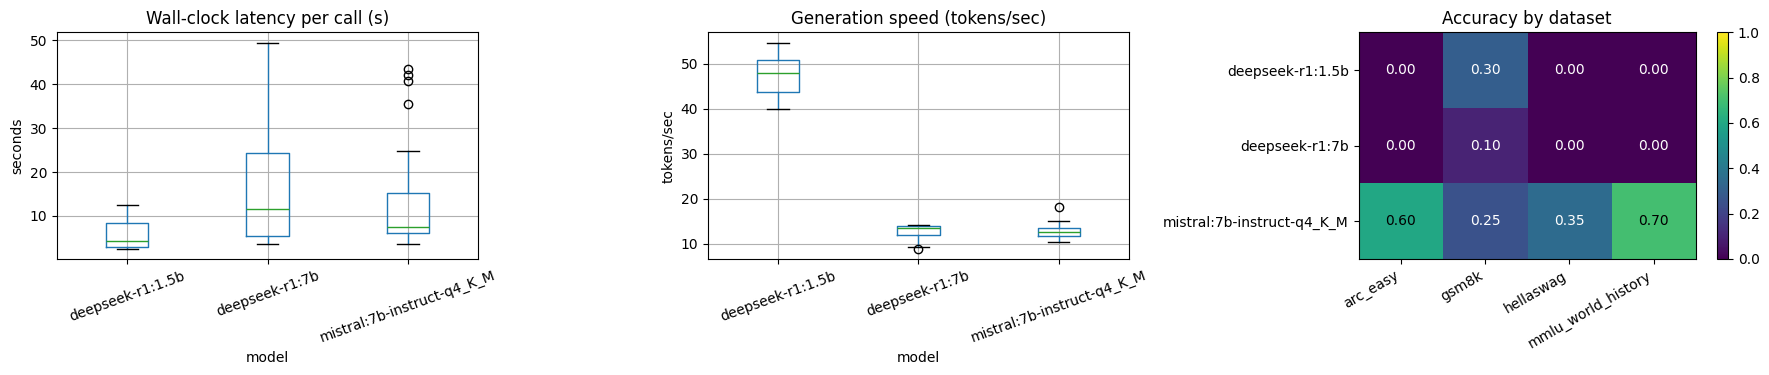

In [12]:
import matplotlib.pyplot as plt

if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Latency by model
    df.boxplot(column='wall_seconds', by='model', ax=axes[0])
    axes[0].set_title('Wall-clock latency per call (s)')
    axes[0].set_ylabel('seconds')
    axes[0].tick_params(axis='x', rotation=20)

    # Throughput by model
    df.boxplot(column='tokens_per_sec', by='model', ax=axes[1])
    axes[1].set_title('Generation speed (tokens/sec)')
    axes[1].set_ylabel('tokens/sec')
    axes[1].tick_params(axis='x', rotation=20)

    # Accuracy heatmap (only scoreable tasks)
    scoreable = df[df['correct'].notna()]
    if not scoreable.empty:
        pivot = scoreable.pivot_table(index='model', columns='dataset', values='correct', aggfunc='mean')
        im = axes[2].imshow(pivot.values, vmin=0, vmax=1, cmap='viridis', aspect='auto')
        axes[2].set_xticks(range(len(pivot.columns))); axes[2].set_xticklabels(pivot.columns, rotation=30, ha='right')
        axes[2].set_yticks(range(len(pivot.index))); axes[2].set_yticklabels(pivot.index)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                v = pivot.values[i, j]
                axes[2].text(j, i, f'{v:.2f}' if pd.notna(v) else '-', ha='center', va='center',
                             color='white' if pd.notna(v) and v < 0.5 else 'black')
        axes[2].set_title('Accuracy by dataset')
        fig.colorbar(im, ax=axes[2])

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

## 11. Persist results

In [ ]:
from datetime import datetime

stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
out_dir = f'benchmark_results_{stamp}'
os.makedirs(out_dir, exist_ok=True)

df.to_csv(os.path.join(out_dir, 'raw_results.csv'), index=False)
agg.to_csv(os.path.join(out_dir, 'per_model_dataset.csv'))
model_summary.to_csv(os.path.join(out_dir, 'per_model_summary.csv'))

with open(os.path.join(out_dir, 'device_info.json'), 'w') as f:
    json.dump(DEVICE_INFO, f, indent=2, default=str)

report = {
    'timestamp': stamp,
    'device': DEVICE_INFO,
    'models': MODELS,
    'datasets': sorted({it['dataset'] for it in EVAL_ITEMS}),
    'max_items_per_dataset': MAX_ITEMS_PER_DATASET,
    'total_eval_items': len(EVAL_ITEMS),
    'model_info': MODEL_INFO,
    'per_model_summary': json.loads(model_summary.reset_index().to_json(orient='records')),
    'per_model_dataset': json.loads(agg.reset_index().to_json(orient='records')),
}
with open(os.path.join(out_dir, 'report.json'), 'w') as f:
    json.dump(report, f, indent=2, default=str)


print('Saved to:', os.path.abspath(out_dir))print(os.listdir(out_dir))

Saved to: C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\benchmark_results_20260511_203433
['device_info.json', 'per_model_dataset.csv', 'per_model_summary.csv', 'raw_results.csv', 'report.json']


## 12. (Optional) Free model memory in Ollama

Ollama keeps models loaded for a while. You can force unload by sending a generate request with `keep_alive: 0`.

In [14]:
for m in MODELS:
    try:
        requests.post(f'{OLLAMA_URL}/api/generate', json={'model': m, 'prompt': '', 'keep_alive': 0}, timeout=30)
        print('Unloaded', m)
    except Exception as e:
        print('Could not unload', m, ':', e)

Unloaded mistral:7b-instruct-q4_K_M
Unloaded deepseek-r1:1.5b
Unloaded deepseek-r1:7b
